In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

DATA_DIR = Path("****")# Path settings

## No cut mock data(lightcone)

In [13]:
snap_range = range(21,43)
zsnap_list = []
Nz_list = []
ncom_list = []
for i in snap_range:
    area = 1048.346611175581
    snap = f"/data/PFS/Uchuu_nu2GC_DESI/lc/Uchuu_nu2GC_lightcone_snap{i}.hdf5"#Path settings
    with h5py.File(snap, "r") as f:
        header = dict(f["Header"].attrs)

        Ngals = header["Ngals"]
        zmin = header["zmin"]
        zmax = header["zmax"]
        zsnap = header["zsnap"]

        dz = zmax - zmin
        Nz = Ngals / dz / area
        zsnap_list.append(zsnap)
        Nz_list.append(Nz)

        chi_max = header["chimax"]
        chi_min = header["chimin"]
        area_sr = area * (np.pi / 180.0)**2
        V_com = area_sr / 3 *(chi_max**3 - chi_min**3)
        n_com = Ngals / V_com
        ncom_list.append(n_com)

## DESI NGC and SGC data

In [14]:
NGC_txt = DATA_DIR / "ELG_LOPnotqso_NGC_nz.txt"
NGC_data = np.loadtxt(NGC_txt, comments="#")

zmid_NGC = NGC_data[:, 0]
zmin_NGC = NGC_data[:, 1]
zmax_NGC = NGC_data[:, 2]
Nbin_NGC = NGC_data[:, 4]
Vbin_NGC = NGC_data[:, 5]
dz_NGC= zmax_NGC - zmin_NGC

area = 2865.3575767653106
Nz_NGC = Nbin_NGC / dz_NGC / area

In [15]:
SGC_txt = DATA_DIR / "ELG_LOPnotqso_SGC_nz.txt"
SGC_data = np.loadtxt(SGC_txt, comments="#")

zmid_SGC = SGC_data[:, 0]
zmin_SGC = SGC_data[:, 1]
zmax_SGC = SGC_data[:, 2]
Nbin_SGC = SGC_data[:, 4]
Vbin_SGC = SGC_data[:, 5]
dz_SGC= zmax_SGC - zmin_SGC

area = 1269.7678900669487
Nz_SGC  = Nbin_SGC / dz_SGC / area

## Plot

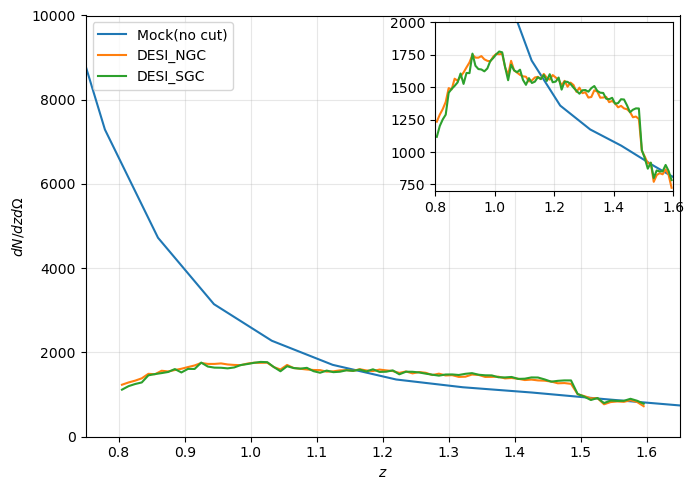

In [16]:
fig, ax = plt.subplots(figsize=(7,5))
plt.plot(zsnap_list, Nz_list, label="Mock(no cut)")
plt.plot(zmid_NGC, Nz_NGC, label="DESI_NGC")
plt.plot(zmid_SGC, Nz_SGC, label="DESI_SGC")
plt.xlim(0.75, 1.65)
plt.ylim(0,10000)
plt.xlabel(r"$z$")
plt.ylabel(r"$dN/dzd\Omega$")
plt.grid(alpha=0.3)
plt.tight_layout()

axins = inset_axes(
    ax,
    width="40%",  
    height="40%",
    loc="upper right"  
)

axins.plot(zsnap_list, Nz_list, label="Mock(no cut)")
axins.plot(zmid_NGC, Nz_NGC, label="DESI_NGC")
axins.plot(zmid_SGC, Nz_SGC, label="DESI_SGC")
axins.set_xlim(0.8, 1.6)
axins.set_ylim(700, 2e3)

axins.grid(alpha=0.3)
ax.legend(loc="upper left")
plt.show()